# Colab B — PyTorch From Scratch: 3-Layer Deep Neural Network (No Built-in Layers)

**CMPE 258 — Deep Learning | Spring 2026 | San José State University**

**Author:** Parth  
**Instructor:** Vijay Eranti

---

## Overview

This notebook implements a **3-hidden-layer deep neural network from scratch using PyTorch** — but **without** using any built-in layer classes like `nn.Linear` or `nn.ReLU`. Instead, we manually:
- Initialize weight tensors with `torch.randn`
- Implement forward pass with raw tensor operations
- Use PyTorch autograd (`requires_grad=True`) for automatic differentiation
- Update weights manually with `torch.no_grad()`

### Architecture
```
Input(3) → Linear(64)+ReLU → Linear(32)+Tanh → Linear(16)+ReLU → Linear(1)
```

### Same non-linear equation as Colab A:
$$y = 3x_1^2 + 2\sin(\pi x_2) \cdot x_3 - x_3^3 + 0.5 x_1 x_2 + 1$$

## 1. Environment Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

PyTorch version: 2.10.0+cu128
Device: cuda


## 2. Synthetic Data Generation

In [2]:
# --- Generate synthetic 3-variable non-linear data ---
n_samples = 500
X_np = np.random.uniform(-1, 1, (n_samples, 3))
x1, x2, x3 = X_np[:, 0:1], X_np[:, 1:2], X_np[:, 2:3]

y_np = (3.0 * x1**2
        + 2.0 * np.sin(np.pi * x2) * x3
        - x3**3
        + 0.5 * x1 * x2
        + 1.0)

# Convert to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32, device=device)
y_true = torch.tensor(y_np, dtype=torch.float32, device=device)

print(f'X shape: {X.shape}  |  y shape: {y_true.shape}')
print(f'y range: [{y_true.min():.3f}, {y_true.max():.3f}]')

X shape: torch.Size([500, 3])  |  y shape: torch.Size([500, 1])
y range: [-1.573, 5.604]


## 3. 4D Data Visualization

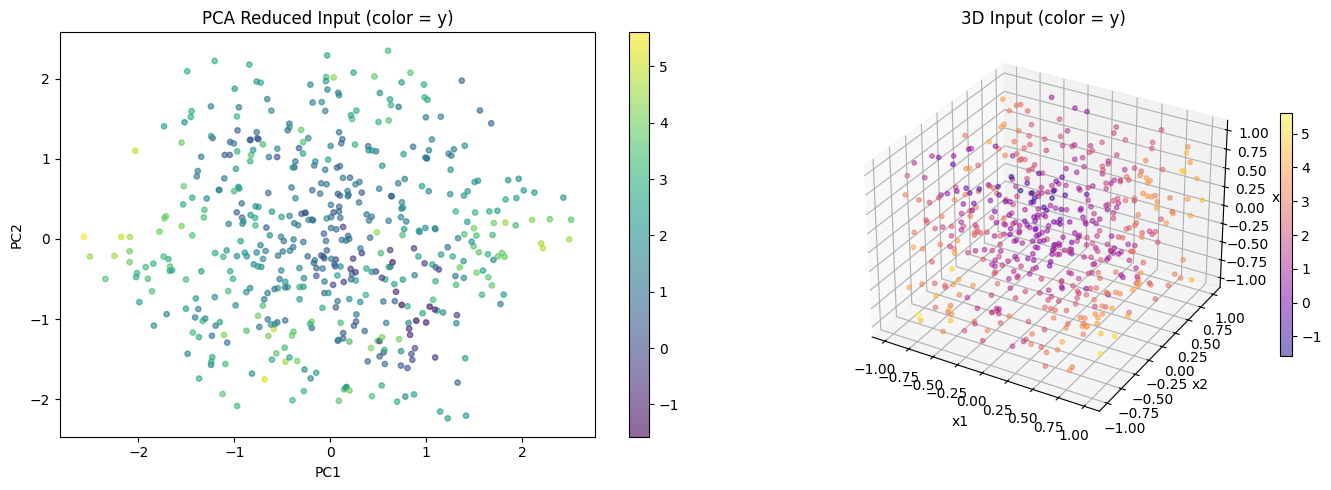

In [3]:
# --- 4D Visualization ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 5))

# PCA 2D
ax1 = fig.add_subplot(121)
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_np.flatten(),
                  cmap='viridis', alpha=0.6, s=15)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('PCA Reduced Input (color = y)')
plt.colorbar(sc1, ax=ax1)

# 3D scatter
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                  c=y_np.flatten(), cmap='plasma', alpha=0.5, s=10)
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.set_title('3D Input (color = y)')
plt.colorbar(sc2, ax=ax2, shrink=0.6)

plt.tight_layout()
plt.show()

## 4. Manual Weight Initialization (No nn.Linear!)

We create raw weight tensors with `requires_grad=True` so PyTorch's autograd can compute gradients automatically — but we still define all operations manually.

In [4]:
# --- Manual weight initialization using He initialization ---
def init_weights(fan_in, fan_out):
    """He initialization: W ~ N(0, sqrt(2/fan_in))"""
    W = torch.randn(fan_in, fan_out, device=device) * np.sqrt(2.0 / fan_in)
    W.requires_grad_(True)
    b = torch.zeros(1, fan_out, device=device, requires_grad=True)
    return W, b

# 3 hidden layers + 1 output layer
# Layer 1: 3 → 64
W1, b1 = init_weights(3, 64)
# Layer 2: 64 → 32
W2, b2 = init_weights(64, 32)
# Layer 3: 32 → 16
W3, b3 = init_weights(32, 16)
# Output: 16 → 1
W4, b4 = init_weights(16, 1)

params = [W1, b1, W2, b2, W3, b3, W4, b4]
print(f'Total parameters: {sum(p.numel() for p in params)}')
for i, (W, b) in enumerate([(W1,b1),(W2,b2),(W3,b3),(W4,b4)]):
    print(f'  Layer {i+1}: W{W.shape} + b{b.shape}')

Total parameters: 2881
  Layer 1: Wtorch.Size([3, 64]) + btorch.Size([1, 64])
  Layer 2: Wtorch.Size([64, 32]) + btorch.Size([1, 32])
  Layer 3: Wtorch.Size([32, 16]) + btorch.Size([1, 16])
  Layer 4: Wtorch.Size([16, 1]) + btorch.Size([1, 1])


## 5. Manual Forward Pass

Each layer: `z = X @ W + b` followed by activation.
No `nn.Linear`, no `nn.ReLU` — just raw tensor operations.

In [5]:
def forward(X):
    """
    Manual forward pass through 3 hidden layers.
    Uses raw torch operations — NO nn.Module, NO nn.Linear.

    Layer 1: z1 = X@W1 + b1, a1 = ReLU(z1)
    Layer 2: z2 = a1@W2 + b2, a2 = Tanh(z2)
    Layer 3: z3 = a2@W3 + b3, a3 = ReLU(z3)
    Output:  out = a3@W4 + b4
    """
    # Hidden layer 1: ReLU
    z1 = X @ W1 + b1
    a1 = torch.relu(z1)

    # Hidden layer 2: Tanh
    z2 = a1 @ W2 + b2
    a2 = torch.tanh(z2)

    # Hidden layer 3: ReLU
    z3 = a2 @ W3 + b3
    a3 = torch.relu(z3)

    # Output layer (linear — regression)
    out = a3 @ W4 + b4
    return out


# Sanity check
y_pred = forward(X)
print(f'Forward pass output shape: {y_pred.shape}')
print(f'Initial prediction range: [{y_pred.min().item():.3f}, {y_pred.max().item():.3f}]')

Forward pass output shape: torch.Size([500, 1])
Initial prediction range: [-0.957, 0.564]


## 6. Training Loop (Manual SGD with Autograd)

We use `loss.backward()` for autograd gradient computation, then manually update parameters with `torch.no_grad()`. No optimizer classes used.

In [6]:
# --- Training Loop ---
num_epochs = 2000
lr = 0.005
loss_history = []

for epoch in range(num_epochs):
    # Forward pass
    y_pred = forward(X)

    # MSE loss (manual computation)
    loss = ((y_pred - y_true) ** 2).mean()
    loss_history.append(loss.item())

    # Backward pass — autograd computes all gradients
    loss.backward()

    # Manual SGD update (no optimizer!)
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()  # reset gradients for next iteration

    if epoch % 200 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:4d}/{num_epochs}  |  Loss: {loss.item():.6f}')

print(f'\nFinal Loss: {loss_history[-1]:.6f}')

Epoch    0/2000  |  Loss: 5.994092
Epoch  200/2000  |  Loss: 0.301802
Epoch  400/2000  |  Loss: 0.223575
Epoch  600/2000  |  Loss: 0.184485
Epoch  800/2000  |  Loss: 0.155839
Epoch 1000/2000  |  Loss: 0.134864
Epoch 1200/2000  |  Loss: 0.119528
Epoch 1400/2000  |  Loss: 0.107257
Epoch 1600/2000  |  Loss: 0.097126
Epoch 1800/2000  |  Loss: 0.088869
Epoch 1999/2000  |  Loss: 0.082389

Final Loss: 0.082389


## 7. Results Visualization

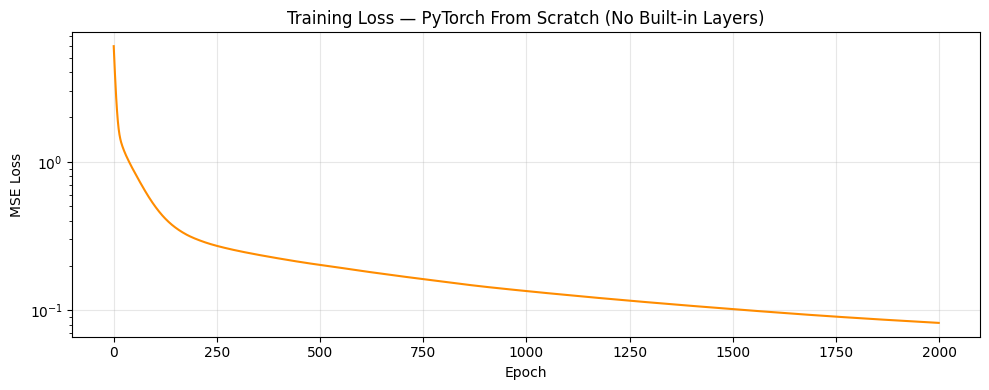

In [7]:
# --- Loss Curve ---
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color='darkorange')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss — PyTorch From Scratch (No Built-in Layers)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

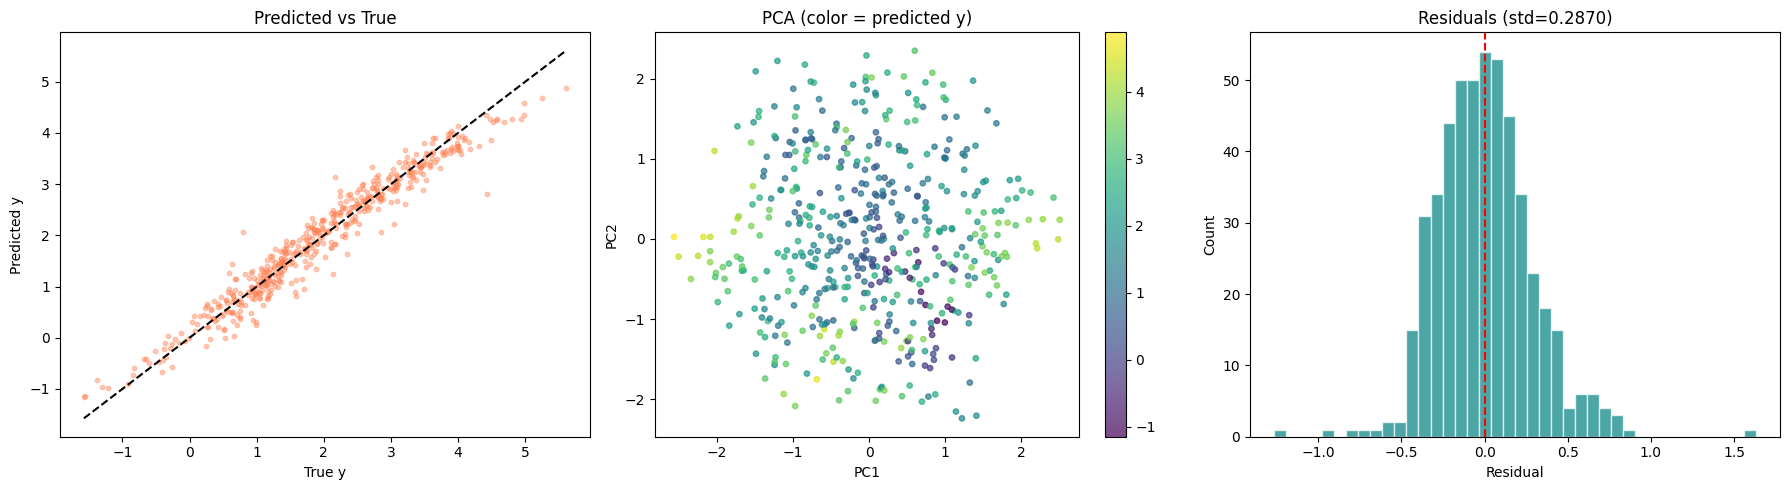

R² score: 0.9490


In [8]:
# --- Predicted vs True ---
with torch.no_grad():
    y_final = forward(X).cpu().numpy()

y_true_np = y_true.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter
axes[0].scatter(y_true_np, y_final, alpha=0.4, s=10, color='coral')
axes[0].plot([y_true_np.min(), y_true_np.max()],
             [y_true_np.min(), y_true_np.max()], 'k--', lw=1.5)
axes[0].set_xlabel('True y'); axes[0].set_ylabel('Predicted y')
axes[0].set_title('Predicted vs True')

# PCA
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_final.flatten(),
                     cmap='viridis', alpha=0.7, s=15)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA (color = predicted y)')
plt.colorbar(sc, ax=axes[1])

# Residuals
residuals = (y_true_np - y_final).flatten()
axes[2].hist(residuals, bins=40, color='teal', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residuals (std={residuals.std():.4f})')

plt.tight_layout()
plt.show()

# R²
ss_res = np.sum((y_true_np - y_final)**2)
ss_tot = np.sum((y_true_np - y_true_np.mean())**2)
print(f'R² score: {1 - ss_res/ss_tot:.4f}')

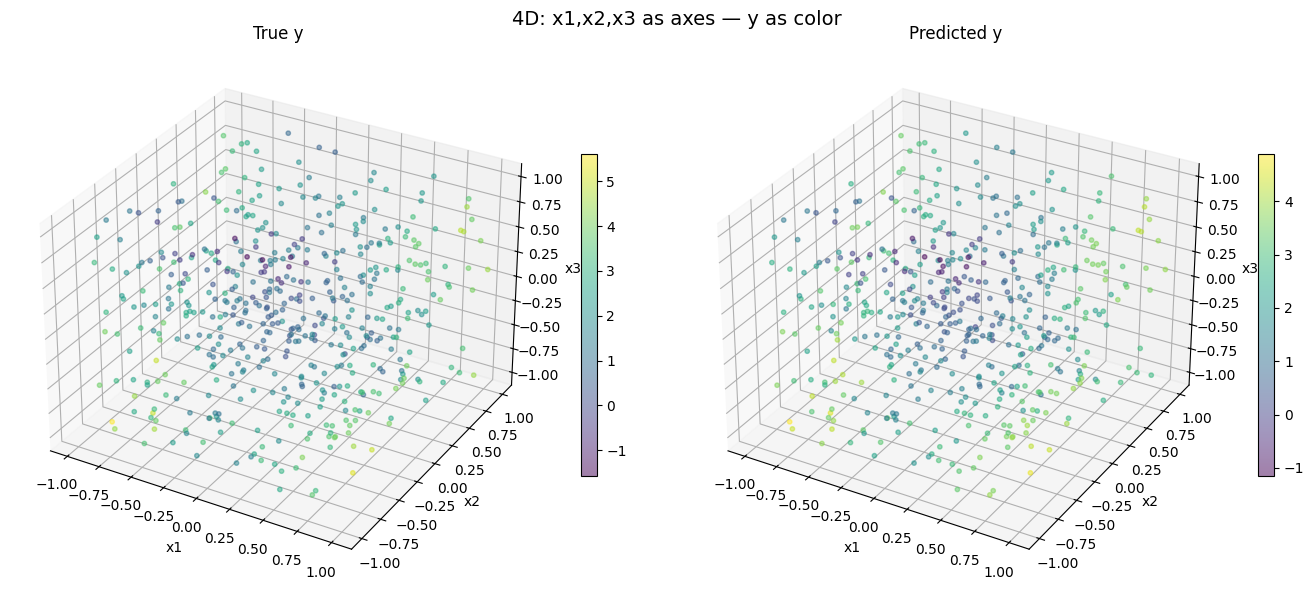

In [9]:
# --- 4D Plot: True vs Predicted ---
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                  c=y_true_np.flatten(), cmap='viridis', alpha=0.5, s=10)
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('x3')
ax1.set_title('True y')
plt.colorbar(sc1, ax=ax1, shrink=0.6)

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2],
                  c=y_final.flatten(), cmap='viridis', alpha=0.5, s=10)
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.set_title('Predicted y')
plt.colorbar(sc2, ax=ax2, shrink=0.6)

plt.suptitle('4D: x1,x2,x3 as axes — y as color', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Summary

| What | How |
|------|-----|
| Layers | Raw `torch.randn` weight tensors — **no `nn.Linear`** |
| Forward | Manual `X @ W + b` + `torch.relu` / `torch.tanh` |
| Backward | `loss.backward()` — PyTorch autograd |
| Optimizer | Manual SGD in `torch.no_grad()` block — **no `optim.SGD`** |
| Architecture | 3 hidden layers: 64 → 32 → 16 |

This demonstrates understanding of the low-level PyTorch computation graph while leveraging autograd for gradient computation.